In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("cardio_preprocessed.csv", sep=",")
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,bmi
0,-0.420325,2,0.438964,-0.858757,-0.121991,-0.090439,1,1,0,0,1,0,21.967120
1,0.314578,1,-1.000949,0.718685,0.068307,-0.038600,3,1,0,0,1,1,34.927679
2,-0.273344,1,0.078985,-0.721588,0.004874,-0.142278,3,1,0,0,0,1,23.507805
3,-0.714286,2,0.558956,0.512932,0.131739,0.013239,1,1,0,0,1,1,28.710479
4,-0.861266,1,-1.000949,-1.270263,-0.185423,-0.194117,1,1,0,0,0,0,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...
66787,0.608540,1,0.078985,0.375763,0.131739,-0.090439,1,1,0,0,1,1,29.384757
66788,1.196462,1,-0.760963,3.530648,0.068307,-0.038600,2,2,0,0,1,1,50.472681
66789,-0.126363,2,2.238854,2.090374,0.322036,-0.038600,3,1,0,1,0,1,31.353579
66790,1.196462,1,-0.161000,-0.172912,0.036590,-0.090439,1,2,0,0,0,1,27.099251


### Appropriate Algorithm Selection

In [3]:
- Supervised Learning
- Binary Classification (0 / 1)
- Output column → cardio (0 / 1)
- Logistic Regression / KNN / Decision Tree / RandomForest / K-Mean / Linear Regression

SyntaxError: invalid character '→' (U+2192) (1863675942.py, line 3)

In [4]:
df["cardio"] = df["cardio"].astype(int)

### Logistic Model

In [5]:
X = df[['age','height','weight','ap_hi','ap_lo']].values
y = df['cardio'].values


## normalize
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

## Initialize Parameters
n_samples, n_features = X.shape
weights = np.zeros(n_features)
bias = 0
learning_rate = 0.01
epochs = 1000


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for _ in range(epochs):
    linear_model = np.dot(X, weights) + bias
    y_predicted = sigmoid(linear_model)

    dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
    db = (1 / n_samples) * np.sum(y_predicted - y)

    weights -= learning_rate * dw
    bias -= learning_rate * db



In [6]:
def predict(X):
    linear_model = np.dot(X, weights) + bias
    y_predicted = sigmoid(linear_model)
    return [1 if i >= 0.5 else 0 for i in y_predicted]

y_pred = predict(X)

accuracy = np.sum(y_pred == y) / len(y)
print("Accuracy:", accuracy)

Accuracy: 0.5120074260390466


## With Library

In [7]:
from sklearn.model_selection import train_test_split,learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score, precision_recall_curve, auc

## LogisticRegression

In [8]:
# Input & Output
X = df.drop("cardio", axis=1)
y = df["cardio"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Model
model = LogisticRegression(max_iter=1000)

# Train (Fit)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (With Library):", accuracy)

Accuracy (With Library): 0.7178681038999926


## RandomForest

In [9]:
# Input & Output
X = df.drop("cardio", axis=1)
y = df["cardio"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Random Forest Model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Fit Model
rf.fit(X_train, y_train)

# Prediction
y_pred = rf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (With Library):", accuracy)

Accuracy (With Library): 0.6937645033310876


## K-Nearest Neighbors (KNN)

In [10]:
# Input & Output
X = df.drop("cardio", axis=1)
y = df["cardio"]

# Feature Scaling (IMPORTANT for KNN)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (With Library):", accuracy)

Accuracy (With Library): 0.6419642188786586


## DecisionTree

In [11]:
# Input & Output
X = df.drop("cardio", axis=1)
y = df["cardio"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Decision Tree model
dt = DecisionTreeClassifier(
    criterion="gini",     # or "entropy"
    random_state=42
)

# Train (Fit)
dt.fit(X_train, y_train)

# Predict 
y_test_pred = dt.predict(X_test)

# Predict on Train data
y_train_pred = dt.predict(X_train)

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("===== MODEL ACCURACY =====")
print("Training Accuracy :", train_accuracy)
print("Testing Accuracy  :", test_accuracy)

# Confusion Matrix
print("\n===== CONFUSION MATRIX =====")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

# Classification Report
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_test_pred))

===== MODEL ACCURACY =====
Training Accuracy : 0.9839237924129284
Testing Accuracy  : 0.612246425630661

===== CONFUSION MATRIX =====
[[3934 2555]
 [2625 4245]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.60      0.61      0.60      6489
           1       0.62      0.62      0.62      6870

    accuracy                           0.61     13359
   macro avg       0.61      0.61      0.61     13359
weighted avg       0.61      0.61      0.61     13359



## Linear Regression

In [12]:
# Input & Output
X = df.drop("cardio", axis=1)
y = df["cardio"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression Model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict (continuous values)
y_pred_continuous = lr.predict(X_test)

# Convert to 0/1 using threshold
y_pred = np.where(y_pred_continuous >= 0.5, 1, 0)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Linear Regression Accuracy:", accuracy)

Linear Regression Accuracy: 0.6414402275619433


## K-Means(Unsupervised)

In [13]:
# Input & True labels
X = df.drop("cardio", axis=1)
y_true = df["cardio"]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

# Cluster labels
clusters = kmeans.labels_

# Map clusters to actual labels
# (swap if needed)
acc1 = accuracy_score(y_true, clusters)
acc2 = accuracy_score(y_true, 1 - clusters)

accuracy = max(acc1, acc2)
print("K-Means Accuracy:", accuracy)

K-Means Accuracy: 0.5020661157024794


## Cross-Validation (Model Stability Check)

In [14]:
from sklearn.model_selection import cross_val_score

# List of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

print("=== Cross-Validation Accuracy ===")
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    print(f"{name}: Mean={scores.mean():.4f}, Std={scores.std():.4f}")
    

=== Cross-Validation Accuracy ===
Logistic Regression: Mean=0.7177, Std=0.0048
KNN: Mean=0.6369, Std=0.0043
Decision Tree: Mean=0.6182, Std=0.0054
Random Forest: Mean=0.6973, Std=0.0041


## Random Forest the BEST
- Reduces Overfitting:
- A single Decision Tree tends to overfit the data.
- Random Forest combines multiple decision trees, which reduces overfitting.
- Handles Complex Medical Data:
- Medical features such as age, blood pressure, and cholesterol have non-linear relationships.
- Random Forest can handle these non-linear patterns effectively.
- Provides High Accuracy:
- According to practical results and research studies, Random Forest gives higher accuracy compared to other models.
- Handles Noise and Outliers:
- Medical datasets often contain noise and outliers.
- Random Forest is more robust and handles them better, which is very important for medical data

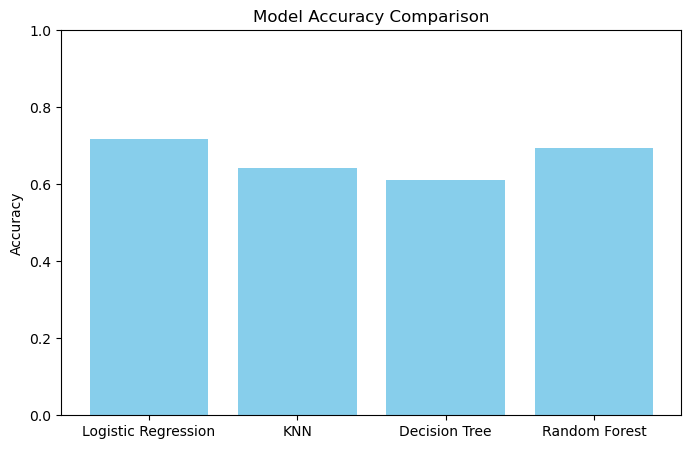

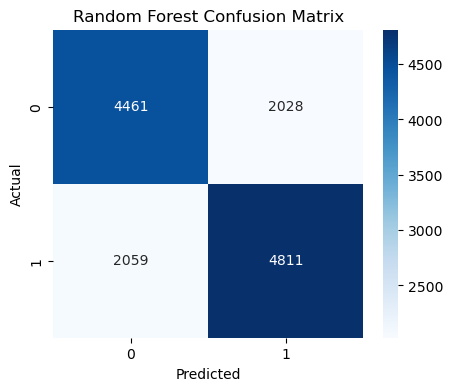

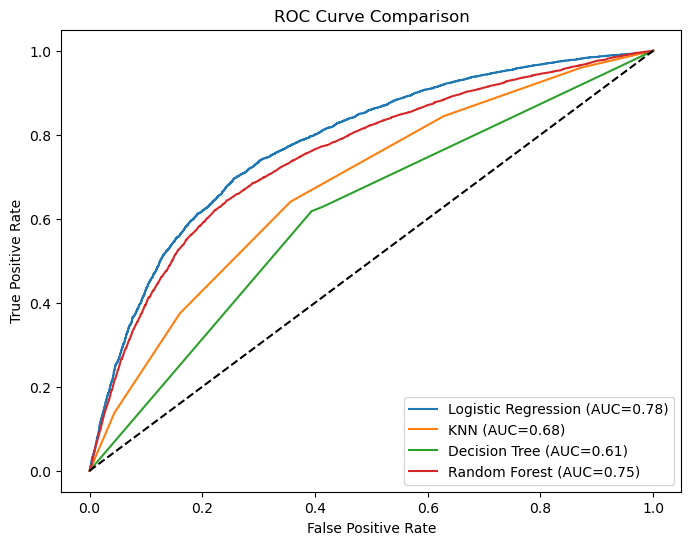

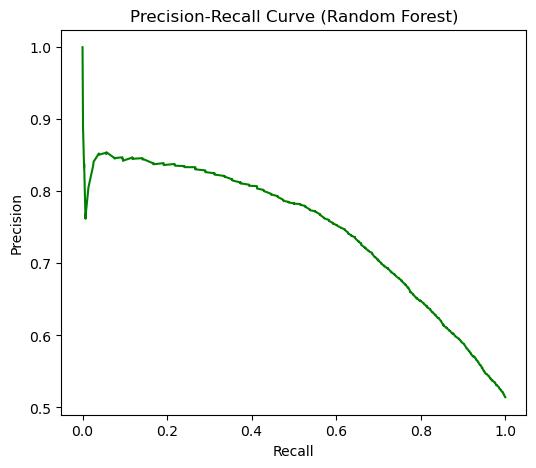

C:\Users\Admin\AppData\Local\Temp\ipykernel_1952\314801307.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X.columns, y=feat_imp, palette='viridis')


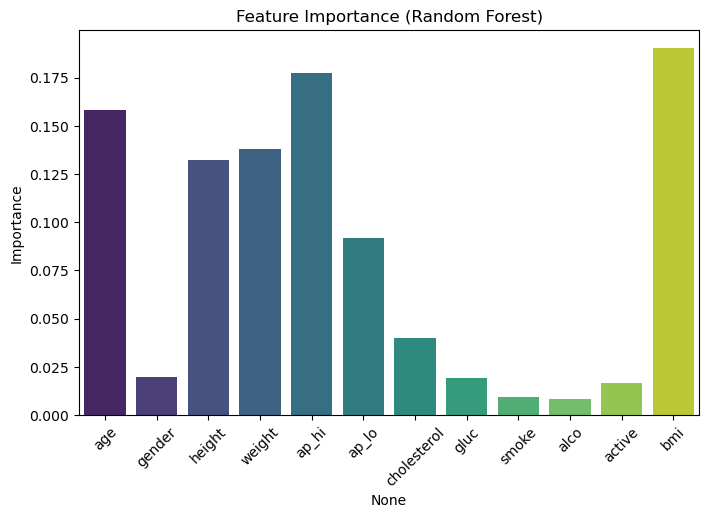

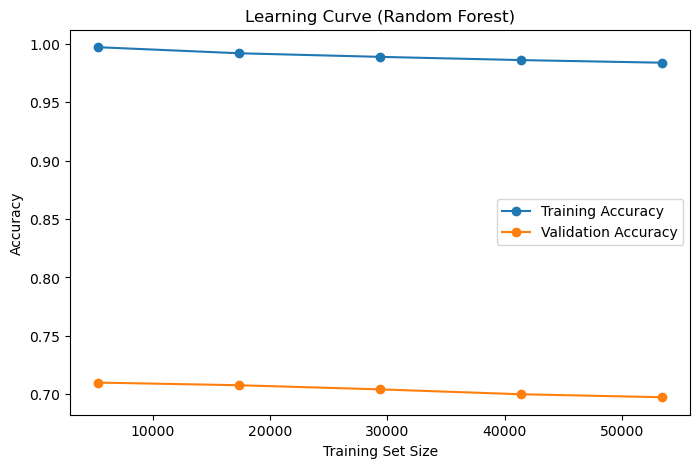

In [15]:

X = df.drop("cardio", axis=1)
y = df["cardio"]

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ----------------------------
#  Train models
# ----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Store predictions and accuracies
accuracies = {}
y_preds = {}
roc_data = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_preds[name] = y_pred
    accuracies[name] = accuracy_score(y_test, y_pred)
    
    # For ROC Curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:  # Decision Tree does have predict_proba, KNN too
        y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_data[name] = (fpr, tpr)

# ----------------------------
#  Accuracy Comparison Graph
# ----------------------------
plt.figure(figsize=(8,5))
plt.bar(accuracies.keys(), accuracies.values(), color='skyblue')
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()

# ----------------------------
#  Confusion Matrix for Random Forest
# ----------------------------
rf_cm = confusion_matrix(y_test, y_preds["Random Forest"])
plt.figure(figsize=(5,4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ----------------------------
#  ROC Curve
# ----------------------------
plt.figure(figsize=(8,6))
for name, (fpr, tpr) in roc_data.items():
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.2f})")
plt.plot([0,1], [0,1], 'k--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ----------------------------
#  Precision-Recall Curve for Random Forest
# ----------------------------
y_prob_rf = models["Random Forest"].predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_prob_rf)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='green')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Random Forest)")
plt.show()

# ----------------------------
#  Feature Importance for Random Forest
# ----------------------------
feat_imp = models["Random Forest"].feature_importances_
plt.figure(figsize=(8,5))
sns.barplot(x=X.columns, y=feat_imp, palette='viridis')
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

# ----------------------------
#  Learning Curve for Random Forest
# ----------------------------
train_sizes, train_scores, val_scores = learning_curve(
    models["Random Forest"], X_scaled, y, cv=5,
    train_sizes=np.linspace(0.1,1.0,5), scoring='accuracy'
)
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Training Accuracy")
plt.plot(train_sizes, val_scores_mean, 'o-', label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Random Forest)")
plt.legend()
plt.show()


In [16]:
# import pickle
# import os
# #pickle is used for serializing and deserializing a Python object structure.

# # Create model folder if not exists
# if not os.path.exists("model"):
#     os.makedirs("model")

# # Save Random Forest model
# pickle.dump(rf, open("model/model.pkl", "wb"))

# # Save scaler used during training
# pickle.dump(scaler, open("model/scaler.pkl", "wb"))

# print("Random Forest model and scaler saved successfully!")

Random Forest model and scaler saved successfully!


In [16]:
import os
import joblib # Much better for sklearn models than pickle

# Create model folder if it doesn't exist
if not os.path.exists("model"):
    os.makedirs("model")

# Save Random Forest model with compression
# compress=3 is a good balance; 9 is max compression
joblib.dump(rf, "model/model.pkl", compress=3)

# Save scaler used during training
joblib.dump(scaler, "model/scaler.pkl", compress=3)

print("Optimized Random Forest model and scaler saved successfully!")

Optimized Random Forest model and scaler saved successfully!
